In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Load the dataset
df = pd.read_csv('/content/Amazon (2).csv')

# Basic inspection
print("Dataset Shape:", df.shape)
display(df.head())
display(df.info())

Dataset Shape: (1000, 17)


,Invoice ID,Branch,City,Customer type,Gender,Product line,Unit price,Quantity,Tax 5%,Total,Date,Time,Payment,cogs,gross margin percentage,gross income,Rating
0,750-67-8428,A,Yangon,Member,Female,Health and beauty,74.69,7,26.1415,548.9715,2019-01-05,13:08:00,Ewallet,522.83,4.761905,26.1415,9.1
1,226-31-3081,C,Naypyitaw,Normal,Female,Electronic accessories,15.28,5,3.8200,80.2200,2019-03-08,10:29:00,Cash,76.40,4.761905,3.8200,9.6
2,631-41-3108,A,Yangon,Normal,Male,Home and lifestyle,46.33,7,16.2155,340.5255,2019-03-03,13:23:00,Credit card,324.31,4.761905,16.2155,7.4
3,123-19-1176,A,Yangon,Member,Male,Health and beauty,58.22,8,23.2880,489.0480,2019-01-27,20:33:00,Ewallet,465.76,4.761905,23.2880,8.4
4,373-73-7910,A,Yangon,Normal,Male,Sports and travel,86.31,7,30.2085,634.3785,2019-02-08,10:37:00,Ewallet,604.17,4.761905,30.2085,5.3


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 17 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   Invoice ID               1000 non-null   object 
 1   Branch                   1000 non-null   object 
 2   City                     1000 non-null   object 
 3   Customer type            1000 non-null   object 
 4   Gender                   1000 non-null   object 
 5   Product line             1000 non-null   object 
 6   Unit price               1000 non-null   float64
 7   Quantity                 1000 non-null   int64  
 8   Tax 5%                   1000 non-null   float64
 9   Total                    1000 non-null   float64
 10  Date                     1000 non-null   object 
 11  Time                     1000 non-null   object 
 12  Payment                  1000 non-null   object 
 13  cogs                     1000 non-null   float64
 14  gross margin percentage  

None

In [2]:
# 2. Feature Engineering

# Convert Date and Time to datetime objects
df['Date'] = pd.to_datetime(df['Date'])
df['Time'] = pd.to_datetime(df['Time'], format='%H:%M:%S').dt.time

# 2.1 Add timeofday column
def get_time_of_day(time_obj):
    hour = time_obj.hour
    if 0 <= hour < 12:
        return 'Morning'
    elif 12 <= hour < 18:
        return 'Afternoon'
    else:
        return 'Evening'

df['timeofday'] = df['Time'].apply(get_time_of_day)

# 2.2 Add dayname column
df['dayname'] = df['Date'].dt.strftime('%a')

# 2.3 Add monthname column
df['monthname'] = df['Date'].dt.strftime('%b')

# Display modified dataframe
display(df[['Date', 'Time', 'timeofday', 'dayname', 'monthname']].head())

,Date,Time,timeofday,dayname,monthname
0,2019-01-05,13:08:00,Afternoon,Sat,Jan
1,2019-03-08,10:29:00,Morning,Fri,Mar
2,2019-03-03,13:23:00,Afternoon,Sun,Mar
3,2019-01-27,20:33:00,Evening,Sun,Jan
4,2019-02-08,10:37:00,Morning,Fri,Feb


In [3]:
# Business Questions 1-11

# 1. Count of distinct cities
distinct_cities = df['City'].nunique()

# 2. Corresponding city for each branch
branch_city = df[['Branch', 'City']].drop_duplicates().sort_values('Branch')

# 3. Count of distinct product lines
distinct_product_lines = df['Product line'].nunique()

# 4. Most frequent payment method
most_freq_payment = df['Payment'].value_counts().idxmax()

# 5. Product line with highest sales (quantity)
highest_sales_pl = df.groupby('Product line')['Quantity'].sum().idxmax()

# 6. Revenue generated each month
monthly_revenue = df.groupby('monthname')['Total'].sum()

# 7. Month with peak COGS
peak_cogs_month = df.groupby('monthname')['cogs'].sum().idxmax()

# 8. Product line with highest revenue
highest_rev_pl = df.groupby('Product line')['Total'].sum().idxmax()

# 9. City with highest revenue
highest_rev_city = df.groupby('City')['Total'].sum().idxmax()

# 10. Product line with highest VAT (Tax 5%)
highest_vat_pl = df.groupby('Product line')['Tax 5%'].sum().idxmax()

# 11. Add 'Good'/'Bad' column based on sales (Total revenue) being above average
avg_sales = df['Total'].mean()
df['performance'] = df['Total'].apply(lambda x: 'Good' if x > avg_sales else 'Bad')

print(f"Distinct Cities: {distinct_cities}")
print(f"Distinct Product Lines: {distinct_product_lines}")
print(f"Most Frequent Payment: {most_freq_payment}")
print(f"Product Line with Highest Sales: {highest_sales_pl}")
print(f"Product Line with Highest Revenue: {highest_rev_pl}")
print(f"City with Highest Revenue: {highest_rev_city}")
display(branch_city)
display(monthly_revenue)
display(df[['Product line', 'Total', 'performance']].head())

Distinct Cities: 3
Distinct Product Lines: 6
Most Frequent Payment: Ewallet
Product Line with Highest Sales: Electronic accessories
Product Line with Highest Revenue: Food and beverages
City with Highest Revenue: Naypyitaw


,Branch,City
0,A,Yangon
9,B,Mandalay
1,C,Naypyitaw


,Total
monthname,
Feb,97219.374
Jan,116291.868
Mar,109455.507


,Product line,Total,performance
0,Health and beauty,548.9715,Good
1,Electronic accessories,80.2200,Bad
2,Home and lifestyle,340.5255,Good
3,Health and beauty,489.0480,Good
4,Sports and travel,634.3785,Good


In [4]:
# Business Questions 12-28

# 12. Branch that exceeded average products sold
avg_qty = df['Quantity'].mean()
branch_qty = df.groupby('Branch')['Quantity'].sum()
print(f"Average Quantity per row: {avg_qty}")
print("Branches exceeding total average logic (per transaction):", df.groupby('Branch')['Quantity'].mean() > avg_qty)

# 13. Most frequent product line by gender
print("Most frequent product line per gender:")
display(df.groupby(['Gender', 'Product line']).size().reset_index(name='count').sort_values(['Gender','count'], ascending=False).groupby('Gender').head(1))

# 14. Average rating for each product line
print("Average rating per product line:")
display(df.groupby('Product line')['Rating'].mean())

# 15. Count of sales for each time of day per weekday
print("Sales occurrences per time of day and weekday:")
display(df.groupby(['dayname', 'timeofday']).size().unstack())

# 16. Customer type contributing highest revenue
print(f"Highest revenue customer type: {df.groupby('Customer type')['Total'].sum().idxmax()}")

# 17. City with highest VAT percentage (Note: Tax is fixed at 5%, so we look at total tax sum)
print(f"City with highest VAT sum: {df.groupby('City')['Tax 5%'].sum().idxmax()}")

# 18. Customer type with highest VAT payments
print(f"Customer type with highest VAT: {df.groupby('Customer type')['Tax 5%'].sum().idxmax()}")

# 19. Count of distinct customer types
print(f"Distinct customer types: {df['Customer type'].nunique()}")

# 20. Count of distinct payment methods
print(f"Distinct payment methods: {df['Payment'].nunique()}")

# 21. Most frequent customer type
print(f"Most frequent customer type: {df['Customer type'].value_counts().idxmax()}")

# 22. Customer type with highest purchase frequency
print(f"Highest purchase frequency customer type: {df['Customer type'].value_counts().idxmax()}")

# 23. Predominant gender
print(f"Predominant gender: {df['Gender'].value_counts().idxmax()}")

# 24. Gender distribution within each branch
print("Gender distribution per branch:")
display(pd.crosstab(df['Branch'], df['Gender']))

# 25. Time of day with most ratings
print(f"Time of day with most ratings: {df.groupby('timeofday')['Rating'].count().idxmax()}")

# 26. Time of day with highest ratings per branch
print("Highest rated time of day per branch:")
display(df.groupby(['Branch', 'timeofday'])['Rating'].mean().unstack().idxmax(axis=1))

# 27. Day of week with highest average ratings
print(f"Day with highest average rating: {df.groupby('dayname')['Rating'].mean().idxmax()}")

# 28. Day of week with highest average ratings per branch
print("Highest rated day per branch:")
display(df.groupby(['Branch', 'dayname'])['Rating'].mean().unstack().idxmax(axis=1))

Average Quantity per row: 5.51
Branches exceeding total average logic (per transaction): Branch
A    False
B    False
C     True
Name: Quantity, dtype: bool
Most frequent product line per gender:


,Gender,Product line,count
9,Male,Health and beauty,88
1,Female,Fashion accessories,96


Average rating per product line:


,Rating
Product line,
Electronic accessories,6.924706
Fashion accessories,7.029213
Food and beverages,7.113218
Health and beauty,7.003289
Home and lifestyle,6.837500
Sports and travel,6.916265


Sales occurrences per time of day and weekday:


...

Gender,Female,Male
Branch,,
A,161,179
B,162,170
C,178,150


Time of day with most ratings: Afternoon
Highest rated time of day per branch:


,0
Branch,
A,Afternoon
B,Morning
C,Afternoon


Day with highest average rating: Mon
Highest rated day per branch:


,0
Branch,
A,Fri
B,Mon
C,Fri


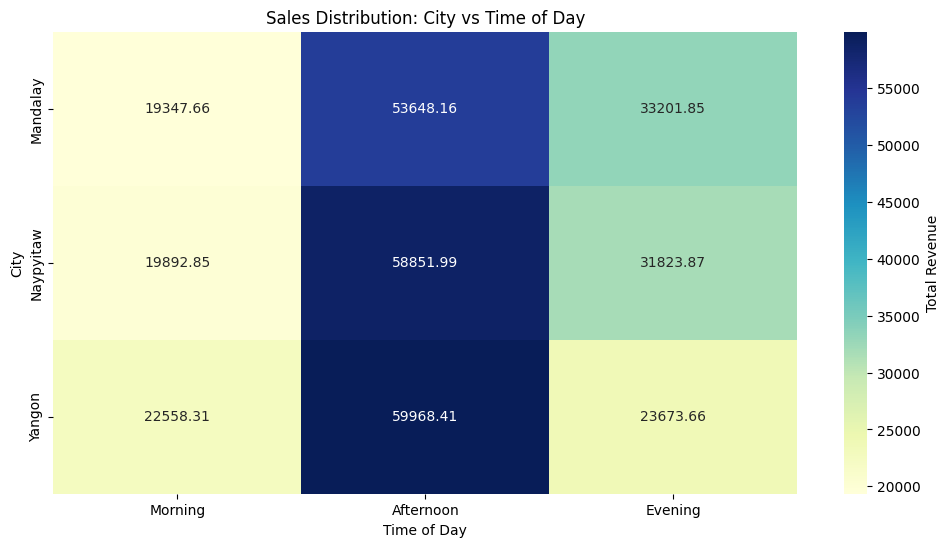

In [5]:
import seaborn as sns
import matplotlib.pyplot as plt

# Pivot data for heatmap: Total revenue by City and Time of Day
city_time_sales = df.pivot_table(values='Total', index='City', columns='timeofday', aggfunc='sum')

# Reorder columns for logical flow
column_order = ['Morning', 'Afternoon', 'Evening']
city_time_sales = city_time_sales.reindex(columns=column_order)

plt.figure(figsize=(12, 6))
sns.heatmap(city_time_sales, annot=True, fmt='.2f', cmap='YlGnBu', cbar_kws={'label': 'Total Revenue'})
plt.title('Sales Distribution: City vs Time of Day')
plt.xlabel('Time of Day')
plt.ylabel('City')
plt.show()